In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv')

In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
0,2019-12-31,72.482498,73.419998,72.379997,73.412498,71.520821,100805600,NaN,NaN,0.000000,NaN
1,2020-01-02,74.059998,75.150002,73.797501,75.087502,73.152649,135480400,2020-01-02,AAPL,0.376125,8.0
2,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.441460,146322800,2020-01-03,AAPL,0.103833,6.0
3,2020-01-06,73.447502,74.989998,73.187500,74.949997,73.018677,118387200,2020-01-06,AAPL,0.779300,2.0
4,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.675278,108872000,2020-01-07,AAPL,0.069367,3.0


In [4]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
249,2020-12-24,131.320007,133.460007,131.100006,131.970001,129.679718,54930100,2020-12-24,AAPL,-0.128000,1.0
250,2020-12-28,133.990005,137.339996,133.509995,136.690002,134.317825,124486200,2020-12-28,AAPL,0.288850,2.0
251,2020-12-29,138.050003,138.789993,134.339996,134.869995,132.529404,121047300,2020-12-29,AAPL,0.000000,2.0
252,2020-12-30,135.580002,135.990005,133.399994,133.720001,131.399368,96452100,2020-12-30,AAPL,0.000000,1.0
253,2020-12-31,134.080002,134.740005,131.720001,132.690002,130.387222,99116600,2020-12-31,AAPL,0.076167,3.0


In [5]:
## Cleaning up the data
df = df[["Date", "Close"]]

df.head()

,Date,Close
0,2019-12-31,73.412498
1,2020-01-02,75.087502
2,2020-01-03,74.357498
3,2020-01-06,74.949997
4,2020-01-07,74.597504


In [6]:
df.set_index('Date',inplace=True)

In [7]:
df.head()

,Close
Date,
2019-12-31,73.412498
2020-01-02,75.087502
2020-01-03,74.357498
2020-01-06,74.949997
2020-01-07,74.597504


In [8]:
df.describe()

,Close
count,254.000000
mean,95.260718
std,21.810137
min,56.092499
25%,77.379377
50%,91.421249
75%,115.739374
max,136.690002


## Step 2: Visualize the Data

<Axes: xlabel='Date'>

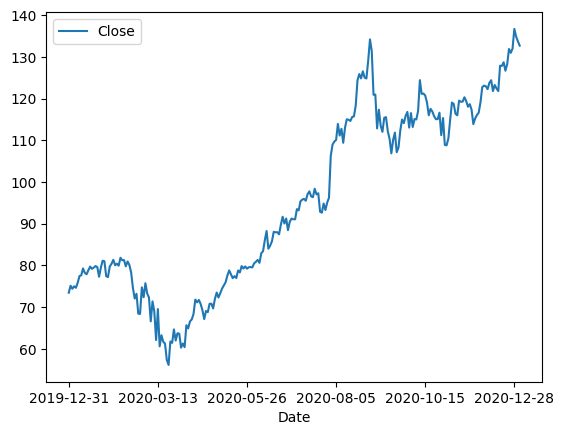

In [9]:
df.plot()

In [10]:
#import sys
#!{sys.executable} -m pip install statsmodels

In [11]:
### Testing For Stationarity

from statsmodels.tsa.stattools import adfuller

In [12]:
test_result=adfuller(df['Close'])

In [13]:
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(sales):
    result=adfuller(sales)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")


In [14]:
adfuller_test(df['Close'])

ADF Test Statistic : -0.12702885454878415
p-value : 0.9466789170863883
#Lags Used : 1
Number of Observations Used : 252
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


### Differencing

In [15]:
df['Close First Difference'] = df['Close'] - df['Close'].shift(1)

In [16]:
df['Close'].shift(1)

Date
2019-12-31           NaN
2020-01-02     73.412498
2020-01-03     75.087502
2020-01-06     74.357498
2020-01-07     74.949997
                 ...    
2020-12-24    130.960007
2020-12-28    131.970001
2020-12-29    136.690002
2020-12-30    134.869995
2020-12-31    133.720001
Name: Close, Length: 254, dtype: float64

In [17]:
df['Weekly Difference']=df['Close']-df['Close'].shift(5)

In [18]:
df.head(14)

,Close,Close First Difference,Weekly Difference
Date,,,
2019-12-31,73.412498,NaN,NaN
2020-01-02,75.087502,1.675003,NaN
2020-01-03,74.357498,-0.730003,NaN
2020-01-06,74.949997,0.592499,NaN
2020-01-07,74.597504,-0.352493,NaN
2020-01-08,75.797501,1.199997,2.385002
2020-01-09,77.407501,1.610001,2.320000
2020-01-10,77.582497,0.174995,3.224998
2020-01-13,79.239998,1.657501,4.290001


In [20]:
## Again test dickey fuller test
adfuller_test(df['Weekly Difference'].dropna())

ADF Test Statistic : -2.5930521955605292
p-value : 0.09444175665195953
#Lags Used : 16
Number of Observations Used : 232
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


<Axes: xlabel='Date'>

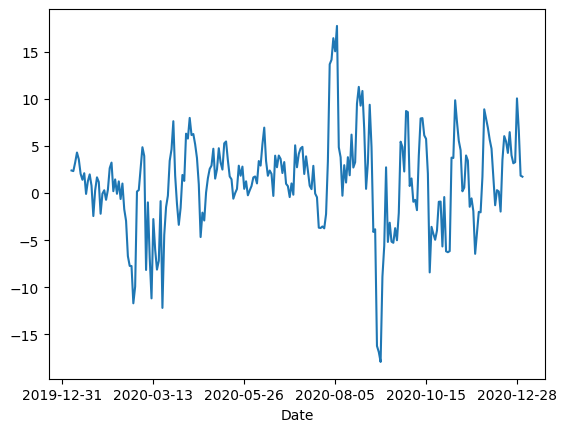

In [21]:
df['Weekly Difference'].plot()

## Auto Regressive Model

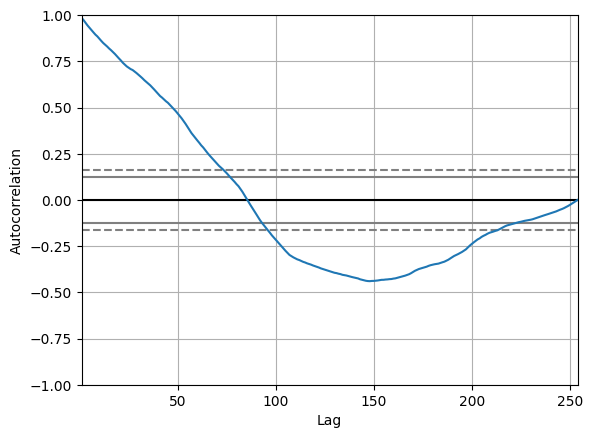

In [22]:
from pandas.plotting import autocorrelation_plot, scatter_matrix
autocorrelation_plot(df['Close'])
plt.show()

## ARIMA Parameters

The ARIMA model uses three important parameters:

- p: number of autoregressive (AR) lags
- d: degree of differencing
- q: number of moving average (MA) lags

Autocorrelation Function (ACF) helps identify the MA component, while Partial Autocorrelation Function (PACF) helps identify the AR component.

In this project, ARIMA is applied to daily stock closing prices after differencing to make the series stationary.

In [23]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import statsmodels.api as sm

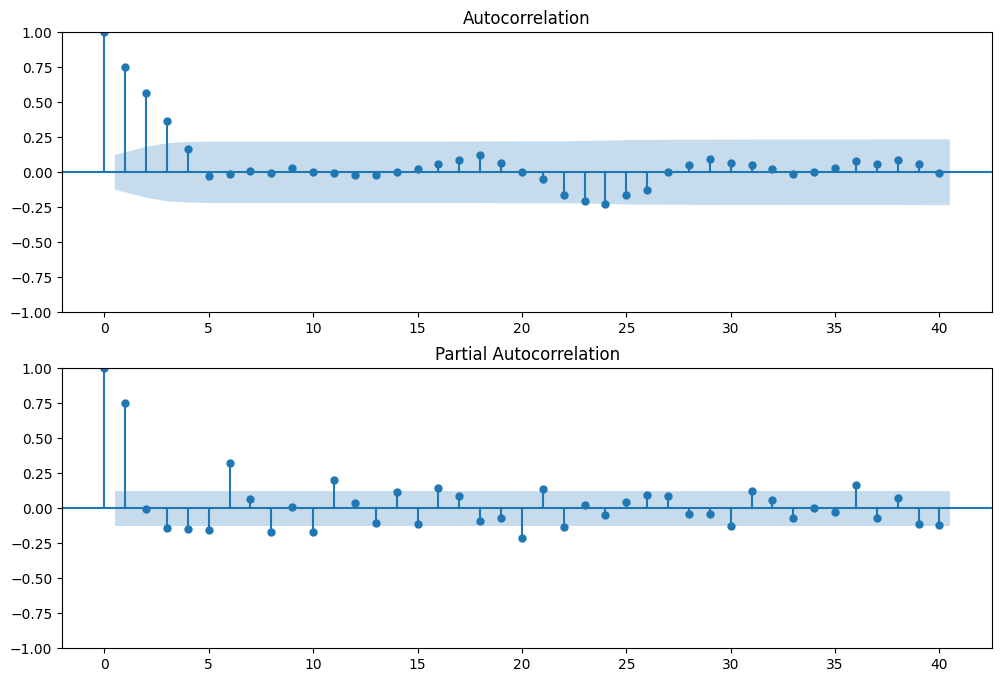

In [25]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['Weekly Difference'].iloc[5:],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['Weekly Difference'].iloc[5:],lags=40,ax=ax2)

In [26]:
# For non-seasonal data
#p=1, d=1, q=0 or 1
from statsmodels.tsa.arima_model import ARIMA

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

model=ARIMA(df['Close'],order=(1,1,1))
model_fit=model.fit()

/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [28]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                  254
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -597.411
Date:                Sun, 17 May 2026   AIC                           1200.821
Time:                        17:15:39   BIC                           1211.422
Sample:                             0   HQIC                          1205.086
                                - 254                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3787      0.264     -1.437      0.151      -0.895       0.138
ma.L1          0.2135      0.281      0.761      0.447      -0.336       0.763
sigma2         6.5837      0.389     16.904      0.000       5.820       7.347
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                81.22
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               1.40   Skew:                            -0.23
Prob(H) (two-sided):                  0.12   Kurtosis:                         5.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: xlabel='Date'>

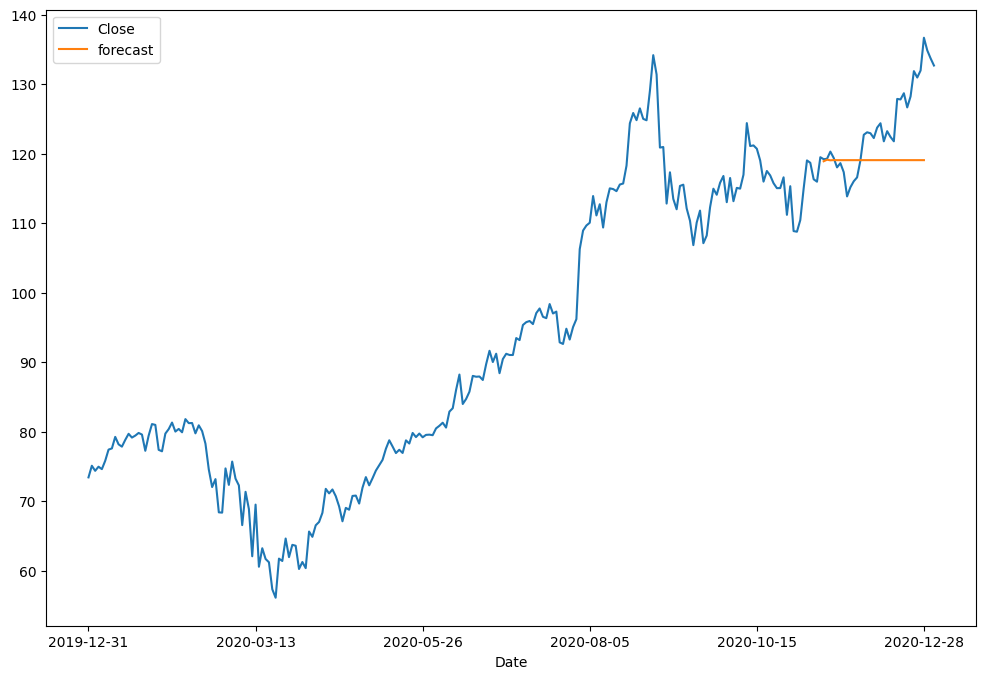

In [30]:
df['forecast']=model_fit.predict(start=220,end=250,dynamic=True)
df[['Close','forecast']].plot(figsize=(12,8))

In [31]:
import statsmodels.api as sm

In [40]:
model=sm.tsa.statespace.SARIMAX(df['Close'],order=(1, 1, 1), seasonal_order=(1,1,1,5))
results=model.fit()

/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [41]:
df.shape

(254, 4)

<Axes: xlabel='Date'>

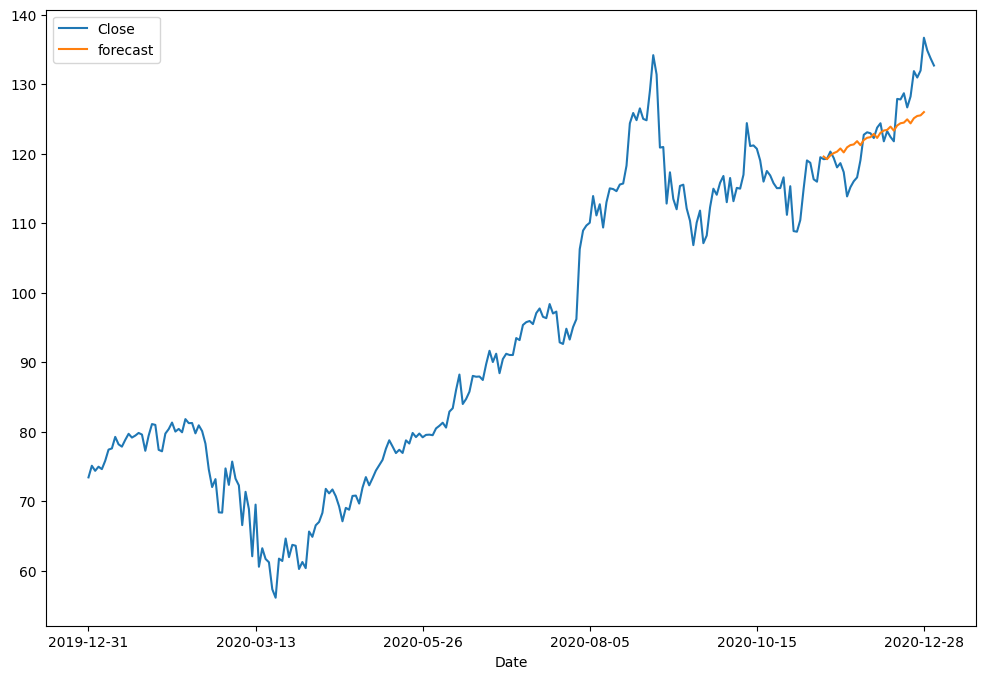

In [42]:
df['forecast']=results.predict(start=220,end=250,dynamic=True)
df[['Close','forecast']].plot(figsize=(12,8))

In [46]:
df.index = pd.to_datetime(df.index)

In [82]:
from pandas.tseries.offsets import BDay

forecast_values = results.forecast(steps=5)

future_dates=[df.index[-1]+ BDay(x)for x in range(1, 6)]


/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [83]:
future_dates

[Timestamp('2021-01-01 00:00:00'),
 Timestamp('2021-01-04 00:00:00'),
 Timestamp('2021-01-05 00:00:00'),
 Timestamp('2021-01-06 00:00:00'),
 Timestamp('2021-01-07 00:00:00')]

In [85]:
future_datest_df=pd.DataFrame(forecast_values.values, 
                              index=future_dates, columns=["forecast"])
final_df = pd.concat([df, future_datest_df])


In [86]:
future_datest_df.tail(30)

,forecast
2021-01-01,132.989890
2021-01-04,133.557340
2021-01-05,133.058511
2021-01-06,133.821778
2021-01-07,133.980112


In [87]:
future_df=pd.concat([df,future_datest_df])

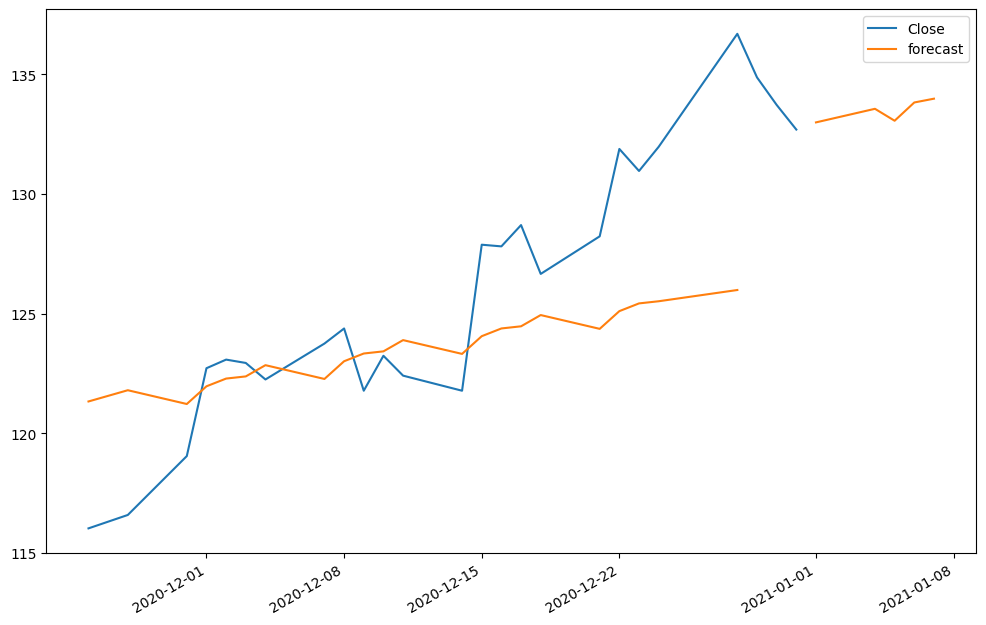

In [91]:
final_df[["Close", "forecast"]].tail(30).plot(figsize=(12,8))
plt.show()

adapted the tutorial forecasting workflow to daily stock market data using business-day future dates

/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


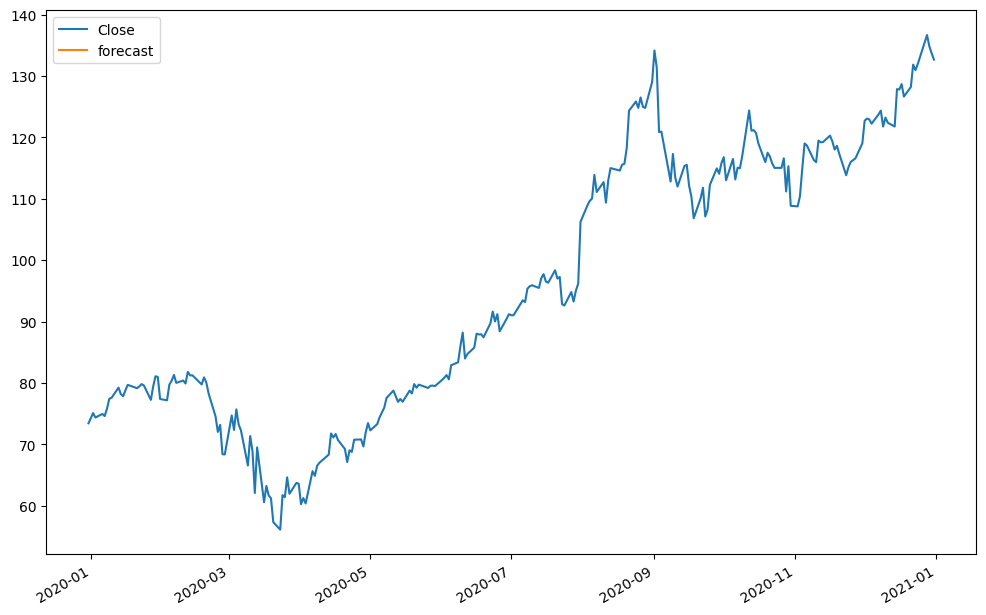

In [92]:
future_df['forecast'] = results.predict(start=len(df), end=len(df)+4, dynamic= True)
future_df[['Close', 'forecast']].plot(figsize=(12, 8))
plt.show()

In [93]:
forecast_table = pd.DataFrame({
    "Forecast Horizon": ["1 Day", "3 Days", "5 Days"],
    "Forecast Date": [
        future_dates[0],
        future_dates[2],
        future_dates[4]
    ],
    "Predicted Close": [
        forecast_values.iloc[0],
        forecast_values.iloc[2],
        forecast_values.iloc[4]
    ]
})

forecast_table

,Forecast Horizon,Forecast Date,Predicted Close
0,1 Day,2021-01-01,132.989890
1,3 Days,2021-01-05,133.058511
2,5 Days,2021-01-07,133.980112


In [107]:
import pandas as pd
import statsmodels.api as sm
from pandas.tseries.offsets import BDay

companies = ["AAPL", "TSLA", "AMZN", "MSFT", "GOOG"]

arima_results = []

for company in companies:

    file_path = f"/home/chakuunaa/BD_ADA_CA2sem2/data/{company.lower()}_features.csv"

    df_company = pd.read_csv(file_path)

    df_company = df_company[["Date", "Close"]]

    df_company["Date"] = pd.to_datetime(df_company["Date"])

    df_company.set_index("Date", inplace=True)

    model = sm.tsa.statespace.SARIMAX(
        df_company["Close"],
        order=(1,1,1),
        seasonal_order=(1,1,1,5)
    )

    results = model.fit(disp=False)

    forecast_values = results.forecast(steps=5)

    arima_results.append({
        "Company": company,
        "1 Day Forecast": forecast_values.iloc[0],
        "3 Day Forecast": forecast_values.iloc[2],
        "5 Day Forecast": forecast_values.iloc[4]
    })

arima_forecast_table = pd.DataFrame(arima_results)

arima_forecast_table

/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, ca

,Company,1 Day Forecast,3 Day Forecast,5 Day Forecast
0,AAPL,132.989890,133.058511,133.980112
1,TSLA,236.448982,237.416045,238.695013
2,AMZN,162.748120,163.394457,164.328273
3,MSFT,221.935273,222.836263,223.516892
4,GOOG,87.436665,87.734829,87.937479
